In [ ]:
#Task 2: Feature Engineering & Preprocessing

In [ ]:
#Encoding categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols
#one_hot_encoding
#It is used for Nominal categories and also when categories are not too many.
df_one_hot_encoding = pd.get_dummies(df, columns=categorical_cols)
df_one_hot_encoding=df_one_hot_encoding.astype(int)
df_one_hot_encoding

,SeniorCitizen,tenure,MonthlyCharges,customerID_0002-ORFBO,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0013-MHZWF,customerID_0014-BMAQU,customerID_0016-QLJIS,customerID_0017-DINOC,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_No,Churn_Yes
0,0,1,29,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,34,56,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,2,53,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,45,42,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,2,70,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,0,72,21,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
7038,0,24,84,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
7039,0,72,103,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
7040,0,11,29,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
#Label Encoding
#It is used for Ordinal data(natural data), Tree based models, Binary categories.
from sklearn.preprocessing import LabelEncoder
df_label_encoding = df.copy()
le = LabelEncoder()
for col in categorical_cols:
    df_label_encoding[col] = le.fit_transform(df_label_encoding[col])
df_label_encoding

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4490,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2137,0
1,3306,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1270,0
2,2155,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,141,1
3,4631,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1212,0
4,5445,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,814,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,1480,0,0,0,0,72,1,0,2,1,...,1,1,1,1,2,1,0,21.15,677,0
7038,4061,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1386,0
7039,1292,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,4777,0
7040,2822,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2538,0


In [ ]:
#Feature Scaling

In [ ]:
#StandardScaler
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print("After Scaling")
print("\n")
print(df[cols_to_scale].round(2))
#print(df[cols_to_scale].describe().round(2))

After Scaling


      SeniorCitizen  tenure  MonthlyCharges
0               0.0   -1.27           -1.06
1               0.0    0.07           -0.16
2               0.0   -1.23           -0.26
3               0.0    0.52           -0.64
4               0.0   -1.23            0.29
...             ...     ...             ...
7037            0.0    1.62           -1.34
7038            0.0   -0.33            0.76
7039            0.0    1.62            1.36
7040            0.0   -0.86           -1.06
7042            0.0    1.37            1.44

[5901 rows x 3 columns]


In [ ]:
#MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
cols_to_scale = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print("After Scaling")
print("\n")
print(df[cols_to_scale].round(2))


After Scaling


      SeniorCitizen  tenure  MonthlyCharges
0               0.0    0.01            0.12
1               0.0    0.47            0.39
2               0.0    0.03            0.35
3               0.0    0.62            0.24
4               0.0    0.03            0.52
...             ...     ...             ...
7037            0.0    1.00            0.03
7038            0.0    0.33            0.66
7039            0.0    1.00            0.85
7040            0.0    0.15            0.11
7042            0.0    0.92            0.87

[5901 rows x 3 columns]


In [ ]:
#Creating new Derived Features

In [ ]:
#Converting 'TotalCharges' to Numeric and Filling NaNs
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
print("Info after TotalCharges conversion:")
df.info()

Info after TotalCharges conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 5901 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5901 non-null   object 
 1   gender            5901 non-null   object 
 2   SeniorCitizen     5901 non-null   float64
 3   Partner           5901 non-null   object 
 4   Dependents        5901 non-null   object 
 5   tenure            5901 non-null   float64
 6   PhoneService      5901 non-null   object 
 7   MultipleLines     5901 non-null   object 
 8   InternetService   5901 non-null   object 
 9   OnlineSecurity    5901 non-null   object 
 10  OnlineBackup      5901 non-null   object 
 11  DeviceProtection  5901 non-null   object 
 12  TechSupport       5901 non-null   object 
 13  StreamingTV       5901 non-null   object 
 14  StreamingMovies   5901 non-null   object 
 15  Contract          5901 non-null   object 
 16  PaperlessBi

/tmp/ipykernel_130368/670765147.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [ ]:
"""
Derived Feature: Average Monthly Spend (AvgMonthlySpend)
This feature represents the average amount a customer spends per month by dividing their total charges by their tenure. To avoid division by zero errors, tenure values of 0 will result in an
AvgMonthlySpend of 0.
"""


'\nDerived Feature: Average Monthly Spend (AvgMonthlySpend)\nThis feature represents the average amount a customer spends per month by dividing their total charges by their tenure. To avoid division by zero errors, tenure values of 0 will result in an\nAvgMonthlySpend of 0.\n'

In [ ]:
df['AvgMonthlySpend'] = df.apply(lambda row: row['TotalCharges'] / row['tenure']
  if row['tenure'] != 0 else 0, axis=1)
print("First 5 rows with 'AvgMonthlySpend':")
display(df[['MonthlyCharges', 'TotalCharges', 'tenure', 'AvgMonthlySpend']].head())

First 5 rows with 'AvgMonthlySpend':


,MonthlyCharges,TotalCharges,tenure,AvgMonthlySpend
0,0.115423,29.85,0.013889,2149.200000
1,0.385075,1889.50,0.472222,4001.294118
2,0.354229,108.15,0.027778,3893.400000
3,0.239303,1840.75,0.625000,2945.200000
4,0.521891,151.65,0.027778,5459.400000


In [ ]:
"""
Derived Feature: Number of Extra Services (ServiceCount)
This feature counts the number of additional services a customer subscribes to, such as online security, backup, device protection, tech support, streaming TV, and streaming movies. 'No internet
service' customers will have 0 extra services related to internet.
"""

"\nDerived Feature: Number of Extra Services (ServiceCount)\nThis feature counts the number of additional services a customer subscribes to, such as online security, backup, device protection, tech support, streaming TV, and streaming movies. 'No internet\nservice' customers will have 0 extra services related to internet.\n"

In [ ]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[service_cols].apply(lambda row: sum(1 for x in row if x == 'Yes'), axis=1)
print("Distribution of 'ServiceCount':")
display(df['ServiceCount'].value_counts())

Distribution of 'ServiceCount':


,count
ServiceCount,
0,2010
3,896
2,817
1,769
4,679
5,485
6,245


In [ ]:
"""
Derived Feature: Has Internet Service (HasInternetService)
This is a binary feature indicating whether a customer subscribes to any internet service (DSL or Fiber optic). This helps differentiate customers who only have phone
service or no service at all.
"""

'\nDerived Feature: Has Internet Service (HasInternetService)\nThis is a binary feature indicating whether a customer subscribes to any internet service (DSL or Fiber optic). This helps differentiate customers who only have phone\nservice or no service at all.\n'

In [ ]:
df['HasInternetService'] = df['InternetService'].apply(lambda x: 1 if x != 'No' else 0)
print("Distribution of 'HasInternetService':")
display(df['HasInternetService'].value_counts())

Distribution of 'HasInternetService':


,count
HasInternetService,
1,4427
0,1474


In [ ]:
#DataFrame after creating derived features

In [ ]:
display(df.head())
df.info()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ServiceCount,HasInternetService
0,7590-VHVEG,Female,0.0,Yes,No,0.013889,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,0.115423,29.85,No,2149.200000,1,1
1,5575-GNVDE,Male,0.0,No,No,0.472222,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,0.385075,1889.50,No,4001.294118,2,1
2,3668-QPYBK,Male,0.0,No,No,0.027778,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,0.354229,108.15,Yes,3893.400000,2,1
3,7795-CFOCW,Male,0.0,No,No,0.625000,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),0.239303,1840.75,No,2945.200000,3,1
4,9237-HQITU,Female,0.0,No,No,0.027778,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,0.521891,151.65,Yes,5459.400000,0,1


<class 'pandas.core.frame.DataFrame'>
Index: 5901 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          5901 non-null   object 
 1   gender              5901 non-null   object 
 2   SeniorCitizen       5901 non-null   float64
 3   Partner             5901 non-null   object 
 4   Dependents          5901 non-null   object 
 5   tenure              5901 non-null   float64
 6   PhoneService        5901 non-null   object 
 7   MultipleLines       5901 non-null   object 
 8   InternetService     5901 non-null   object 
 9   OnlineSecurity      5901 non-null   object 
 10  OnlineBackup        5901 non-null   object 
 11  DeviceProtection    5901 non-null   object 
 12  TechSupport         5901 non-null   object 
 13  StreamingTV         5901 non-null   object 
 14  StreamingMovies     5901 non-null   object 
 15  Contract            5901 non-null   object 
 16  PaperlessBi

In [ ]:
#Feature Selection



In [ ]:
"""
Preparing Data for Feature Selection
Before applying feature selection methods, we need to separate the target variable (Churn) from the features and ensure all features are in a numerical format.
We will use the df_label_encoding DataFrame as it has already converted categorical features into numerical representations using label encoding.
"""

'\nPreparing Data for Feature Selection\nBefore applying feature selection methods, we need to separate the target variable (Churn) from the features and ensure all features are in a numerical format.\nWe will use the df_label_encoding DataFrame as it has already converted categorical features into numerical representations using label encoding.\n'

In [ ]:
from sklearn.model_selection import train_test_split

# Drop customerID as it's an identifier and not a predictive feature
X = df_label_encoding.drop(['customerID', 'Churn'], axis=1)
y = df_label_encoding['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("First 5 rows of features (X):")
display(X.head())

Features shape: (5901, 19)
Target shape: (5901,)
First 5 rows of features (X):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2137
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1270
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,141
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1212
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,814


In [ ]:
"""
1.Feature Importance from Tree-based Models
Tree-based models like Random Forest can provide a score for the importance of each feature in predicting the target variable.
Features with higher scores are considered more important. We'll use RandomForestClassifier for this.
"""

"\n1.Feature Importance from Tree-based Models\nTree-based models like Random Forest can provide a score for the importance of each feature in predicting the target variable.\nFeatures with higher scores are considered more important. We'll use RandomForestClassifier for this.\n"

Top 10 features by RandomForest importance:


,0
MonthlyCharges,0.182490
tenure,0.181072
TotalCharges,0.174468
Contract,0.074918
PaymentMethod,0.055040
OnlineSecurity,0.046729
TechSupport,0.040943
InternetService,0.030395
gender,0.028601
OnlineBackup,0.027855


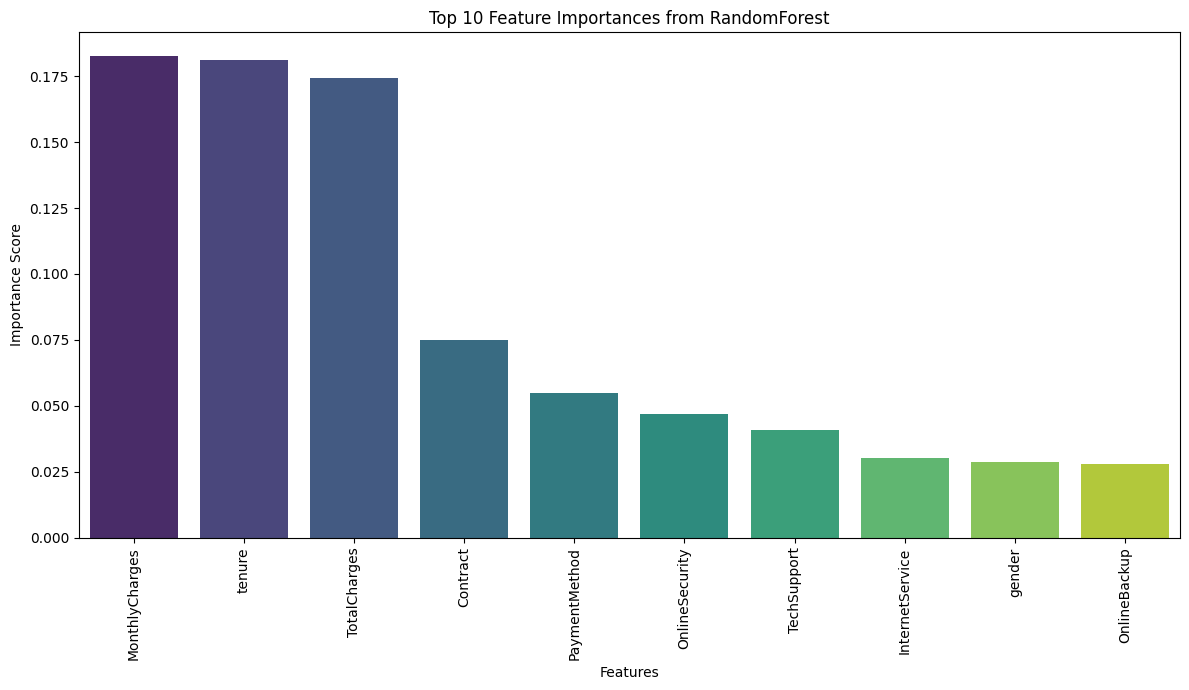

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort and display top features
sorted_feature_importances = feature_importances.sort_values(ascending=False)
print("Top 10 features by RandomForest importance:")
display(sorted_feature_importances.head(10))

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_feature_importances.head(10).index, y=sorted_feature_importances.head(10).values, palette='viridis', hue=sorted_feature_importances.head(10).index, legend=False)
plt.xticks(rotation=90)
plt.title('Top 10 Feature Importances from RandomForest')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
"""
Mutual Information
Mutual information measures the dependency between the variables.
It quantifies the 'amount of information' obtained about one random variable through the other random variable.
It's a non-linear measure and can capture complex relationships. We'll use mutual_info_classif.
"""

"\nMutual Information\nMutual information measures the dependency between the variables.\nIt quantifies the 'amount of information' obtained about one random variable through the other random variable.\nIt's a non-linear measure and can capture complex relationships. We'll use mutual_info_classif.\n"

Top 10 features by Mutual Information score:


,0
Contract,0.089508
tenure,0.066035
OnlineSecurity,0.063301
TechSupport,0.052173
OnlineBackup,0.051771
InternetService,0.045183
PaymentMethod,0.040551
DeviceProtection,0.040034
StreamingTV,0.039655
MonthlyCharges,0.038422


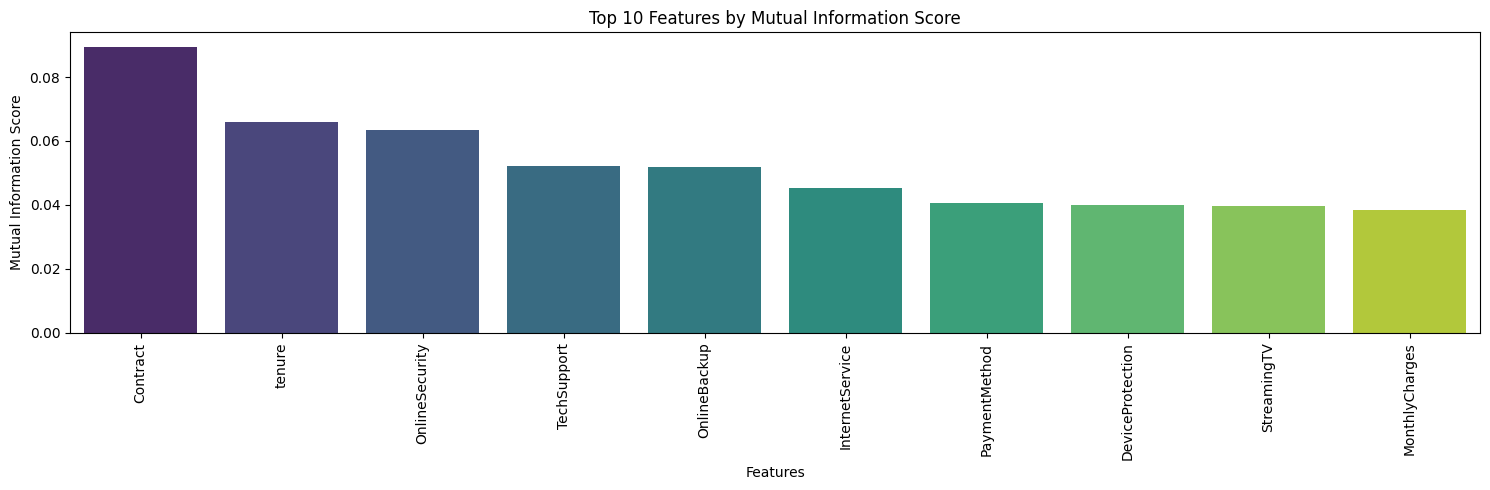

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information scores
mutual_info_scores = mutual_info_classif(X, y, random_state=42)

# Create a Series for better visualization and sorting
mutual_info_series = pd.Series(mutual_info_scores, index=X.columns)

# Sort and display top features
sorted_mutual_info = mutual_info_series.sort_values(ascending=False)
print("Top 10 features by Mutual Information score:")
display(sorted_mutual_info.head(10))

# Plot mutual information scores
plt.figure(figsize=(15, 5))
sns.barplot(x=sorted_mutual_info.head(10).index, y=sorted_mutual_info.head(10).values, palette='viridis', hue=sorted_mutual_info.head(10).index, legend=False)
plt.xticks(rotation=90)
plt.title('Top 10 Features by Mutual Information Score')
plt.ylabel('Mutual Information Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
#Handling class imbalance
#1.SMOTE (Synthetic Minority Over-sampling Technique)
#2.Class Weights

In [ ]:
#1.SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original dataset shape: {Counter(y)}")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(f"Resampled dataset shape with SMOTE: {Counter(y_res)}")

Original dataset shape: Counter({0: 4508, 1: 1393})
Resampled dataset shape with SMOTE: Counter({0: 4508, 1: 4508})


In [ ]:
#2.Class Weights
from sklearn.utils import class_weight

# Calculate class weights
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(zip(np.unique(y), weights))

print(f"Calculated class weights: {class_weights}")

# Example of how to use class weights in a model (e.g., RandomForestClassifier)
from sklearn.ensemble import RandomForestClassifier

# Without class weights
rf_model_no_weights = RandomForestClassifier(random_state=42)
rf_model_no_weights.fit(X, y)

# With class weights
rf_model_with_weights = RandomForestClassifier(class_weight=class_weights, random_state=42)
rf_model_with_weights.fit(X, y)

print("\nRandomForestClassifier models trained with and without class weights.")

Calculated class weights: {np.int64(0): np.float64(0.6545031055900621), np.int64(1): np.float64(2.1180904522613067)}

RandomForestClassifier models trained with and without class weights.


In [ ]:
#Split data
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% for temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)

# Second split: 50% of temp for validation, 50% of temp for test (15% each of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in validation set:")
print(y_val.value_counts(normalize=True))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (6311, 19)
Shape of y_train: (6311,)
Shape of X_val: (1352, 19)
Shape of y_val: (1352,)
Shape of X_test: (1353, 19)
Shape of y_test: (1353,)

Class distribution in training set:
Churn
1    0.500079
0    0.499921
Name: proportion, dtype: float64

Class distribution in validation set:
Churn
1    0.5
0    0.5
Name: proportion, dtype: float64

Class distribution in test set:
Churn
0    0.50037
1    0.49963
Name: proportion, dtype: float64
